# 📊 AutoEstimate — Analyse Exploratoire des Données (EDA)
**Dataset** : Annonces voitures d'occasion Avito.ma — ~30 000 lignes  
**Objectif** : Comprendre les distributions, relations, outliers et patterns avant modélisation


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'figure.facecolor': '#0d0f10',
    'axes.facecolor':   '#151719',
    'axes.edgecolor':   '#2a2d31',
    'axes.labelcolor':  '#e8eaed',
    'xtick.color':      '#9aa0a6',
    'ytick.color':      '#9aa0a6',
    'text.color':       '#e8eaed',
    'grid.color':       '#2a2d31',
    'grid.alpha':       0.5,
    'figure.dpi':       120,
    'font.size':        11,
})
GOLD = '#f0b90b'
RED  = '#e74c3c'
GREEN = '#2ecc71'
BLUE  = '#3498db'

print("✅ Imports OK")


✅ Imports OK


## 2. Chargement & Aperçu rapide

In [2]:
d = pd.read_csv("final_file.csv")

# Nettoyage minimal pour l'EDA (avant encoding)
d['Prix']           = d['Prix'].astype(str).str.replace(r'[^\d.]', '', regex=True)
d['Prix']           = pd.to_numeric(d['Prix'], errors='coerce')
d['Kilométrage']    = d['Kilométrage'].astype(str).str.replace(r'[^\d.]', '', regex=True)
d['Kilométrage']    = pd.to_numeric(d['Kilométrage'], errors='coerce')
d['Puissance fiscale'] = d['Puissance fiscale'].astype(str).str.extract(r'(\d+)').astype(float)
d['Année-Modèle']   = pd.to_numeric(d['Année-Modèle'], errors='coerce')
d['Age']            = 2026 - d['Année-Modèle']

print(f"Shape du dataset : {d.shape}")
print(f"\nColonnes : {list(d.columns)}")
d.head()


Shape du dataset : (12637, 14)

Colonnes : ['Prix', 'Année-Modèle', 'Boite de vitesses', 'Type de carburant', 'Kilométrage', 'Marque', 'Modèle', 'Nombre de portes', 'Origine', 'Première main', 'Puissance fiscale', 'État', 'Équipements', 'Age']


,Prix,Année-Modèle,Boite de vitesses,Type de carburant,Kilométrage,Marque,Modèle,Nombre de portes,Origine,Première main,Puissance fiscale,État,Équipements,Age
0,137000.0,2021.0,Manuelle,Diesel,1.300001e+11,Renault,Clio,5.0,WW au Maroc,Non,6.0,Excellent,"['ABS', 'Airbags', 'CD/MP3/Bluetooth', 'Caméra...",5.0
1,69000.0,2007.0,Manuelle,Diesel,5.001000e+07,Peugeot,207,NaN,NaN,NaN,6.0,Excellent,"['Airbags', 'Climatisation', 'Radar de recul',...",19.0
2,260000.0,2020.0,Automatique,Diesel,8.000085e+09,Jeep,Grand Cherokee,NaN,NaN,NaN,12.0,Excellent,"['ABS', 'Airbags', 'CD/MP3/Bluetooth', 'Caméra...",6.0
3,60000.0,2010.0,Manuelle,Diesel,1.400001e+11,Toyota,Corolla,5.0,Dédouanée,Oui,6.0,Excellent,"['ABS', 'Airbags', 'CD/MP3/Bluetooth', 'Climat...",16.0
4,220000.0,2021.0,Automatique,Diesel,1.500002e+11,Renault,Megane,5.0,WW au Maroc,NaN,6.0,Excellent,[],5.0


## 3. Informations générales

In [3]:
print("=== TYPES & VALEURS MANQUANTES ===")
info = pd.DataFrame({
    'Dtype':    d.dtypes,
    'Non-null': d.notnull().sum(),
    'Null':     d.isnull().sum(),
    'Null %':   (d.isnull().sum() / len(d) * 100).round(2),
    'Unique':   d.nunique()
})
print(info.to_string())


=== TYPES & VALEURS MANQUANTES ===
                     Dtype  Non-null  Null  Null %  Unique
Prix               float64     12634     3    0.02     723
Année-Modèle       float64     12556    81    0.64      45
Boite de vitesses      str     12573    64    0.51       2
Type de carburant      str     12579    58    0.46       5
Kilométrage        float64     12575    62    0.49      37
Marque                 str     12573    64    0.51      66
Modèle                 str     12573    64    0.51     562
Nombre de portes   float64     11266  1371   10.85       2
Origine                str     11231  1406   11.13       4
Première main          str     10916  1721   13.62       2
Puissance fiscale  float64     12577    60    0.47      35
État                   str     12090   547    4.33       7
Équipements            str     12637     0    0.00    2335
Age                float64     12556    81    0.64      45


In [4]:
print("=== STATISTIQUES DESCRIPTIVES ===")
cols_num = ['Prix', 'Kilométrage', 'Année-Modèle', 'Puissance fiscale', 'Nombre de portes', 'Age']
d[cols_num].describe().round(0)


=== STATISTIQUES DESCRIPTIVES ===


,Prix,Kilométrage,Année-Modèle,Puissance fiscale,Nombre de portes,Age
count,12634.0,1.257500e+04,12556.0,12577.0,11266.0,12556.0
mean,170411.0,1.113024e+11,2014.0,8.0,5.0,12.0
std,172955.0,9.718339e+10,8.0,3.0,0.0,8.0
min,15.0,4.999000e+03,1981.0,4.0,3.0,1.0
25%,82000.0,6.500070e+09,2010.0,6.0,5.0,6.0
50%,135000.0,1.200001e+11,2016.0,7.0,5.0,10.0
75%,207000.0,1.900002e+11,2020.0,8.0,5.0,16.0
max,5000000.0,4.500005e+11,2025.0,41.0,5.0,45.0


## 4. Visualisation des valeurs manquantes

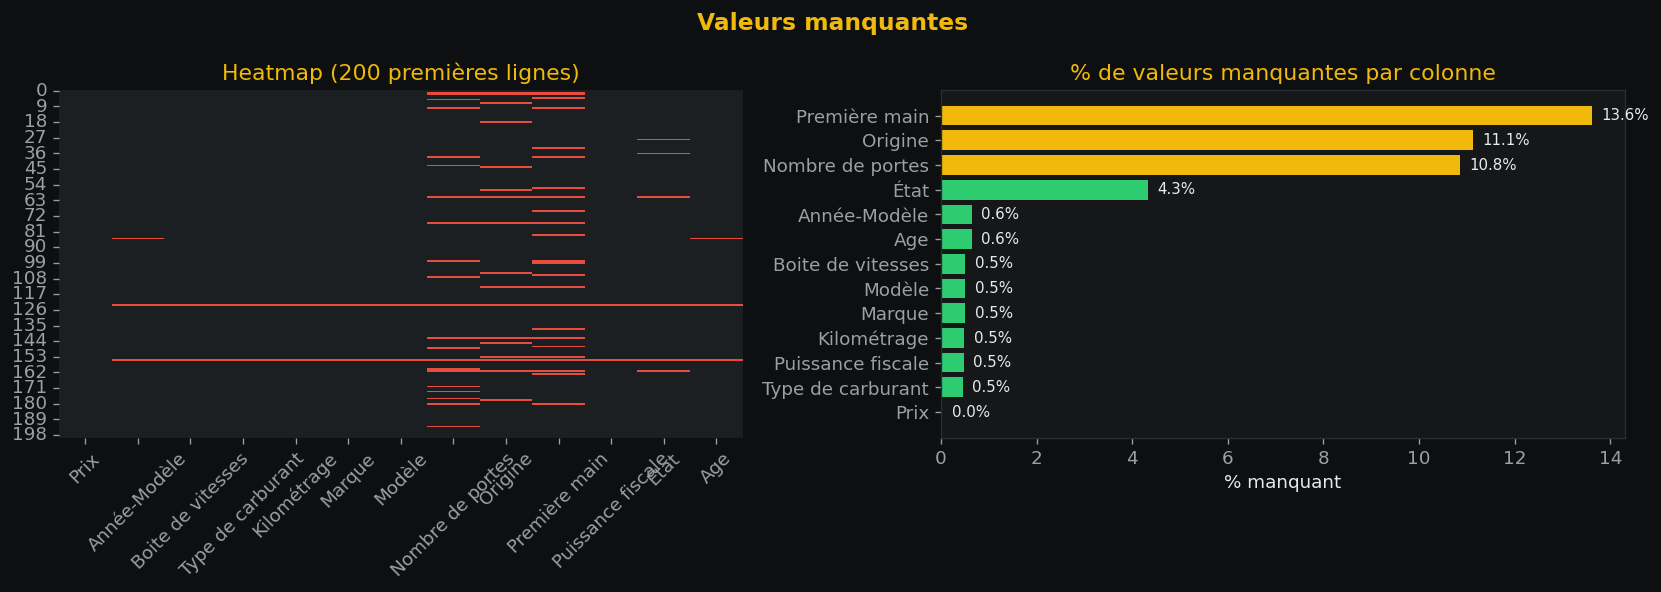

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Valeurs manquantes", fontsize=14, color=GOLD, fontweight='bold')

# Heatmap
missing = d.isnull()
if missing.any().any():
    cols_avec_na = missing.columns[missing.any()].tolist()
    sns.heatmap(missing[cols_avec_na].head(200), cbar=False,
                cmap=['#1c1f22', RED], ax=axes[0])
    axes[0].set_title("Heatmap (200 premières lignes)", color=GOLD)
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, "Aucune valeur manquante", ha='center', va='center',
                 fontsize=14, color=GREEN)
    axes[0].set_title("Heatmap", color=GOLD)

# Barplot % manquants
pct_missing = (d.isnull().sum() / len(d) * 100).sort_values(ascending=True)
pct_missing = pct_missing[pct_missing > 0]
if len(pct_missing) > 0:
    colors = [RED if v > 20 else GOLD if v > 5 else GREEN for v in pct_missing]
    axes[1].barh(pct_missing.index, pct_missing.values, color=colors)
    axes[1].set_xlabel("% manquant")
    axes[1].set_title("% de valeurs manquantes par colonne", color=GOLD)
    for i, v in enumerate(pct_missing.values):
        axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', color='#e8eaed', fontsize=9)
else:
    axes[1].text(0.5, 0.5, "0 valeur manquante ✅", ha='center', va='center',
                 fontsize=14, color=GREEN)
    axes[1].set_title("% manquants", color=GOLD)

plt.tight_layout()
plt.savefig('eda_01_missing.png', bbox_inches='tight', facecolor='#0d0f10')
plt.show()


## 5. Distribution du Prix (variable cible)

Prix brut   — Skewness: 8.777 | Min: 15 | Max: 5,000,000
Prix clean  — Skewness: 0.786 | Min: 15 | Max: 393,000
log(Prix)   — Skewness: -1.403
Outliers supprimés : 673 (5.3%)


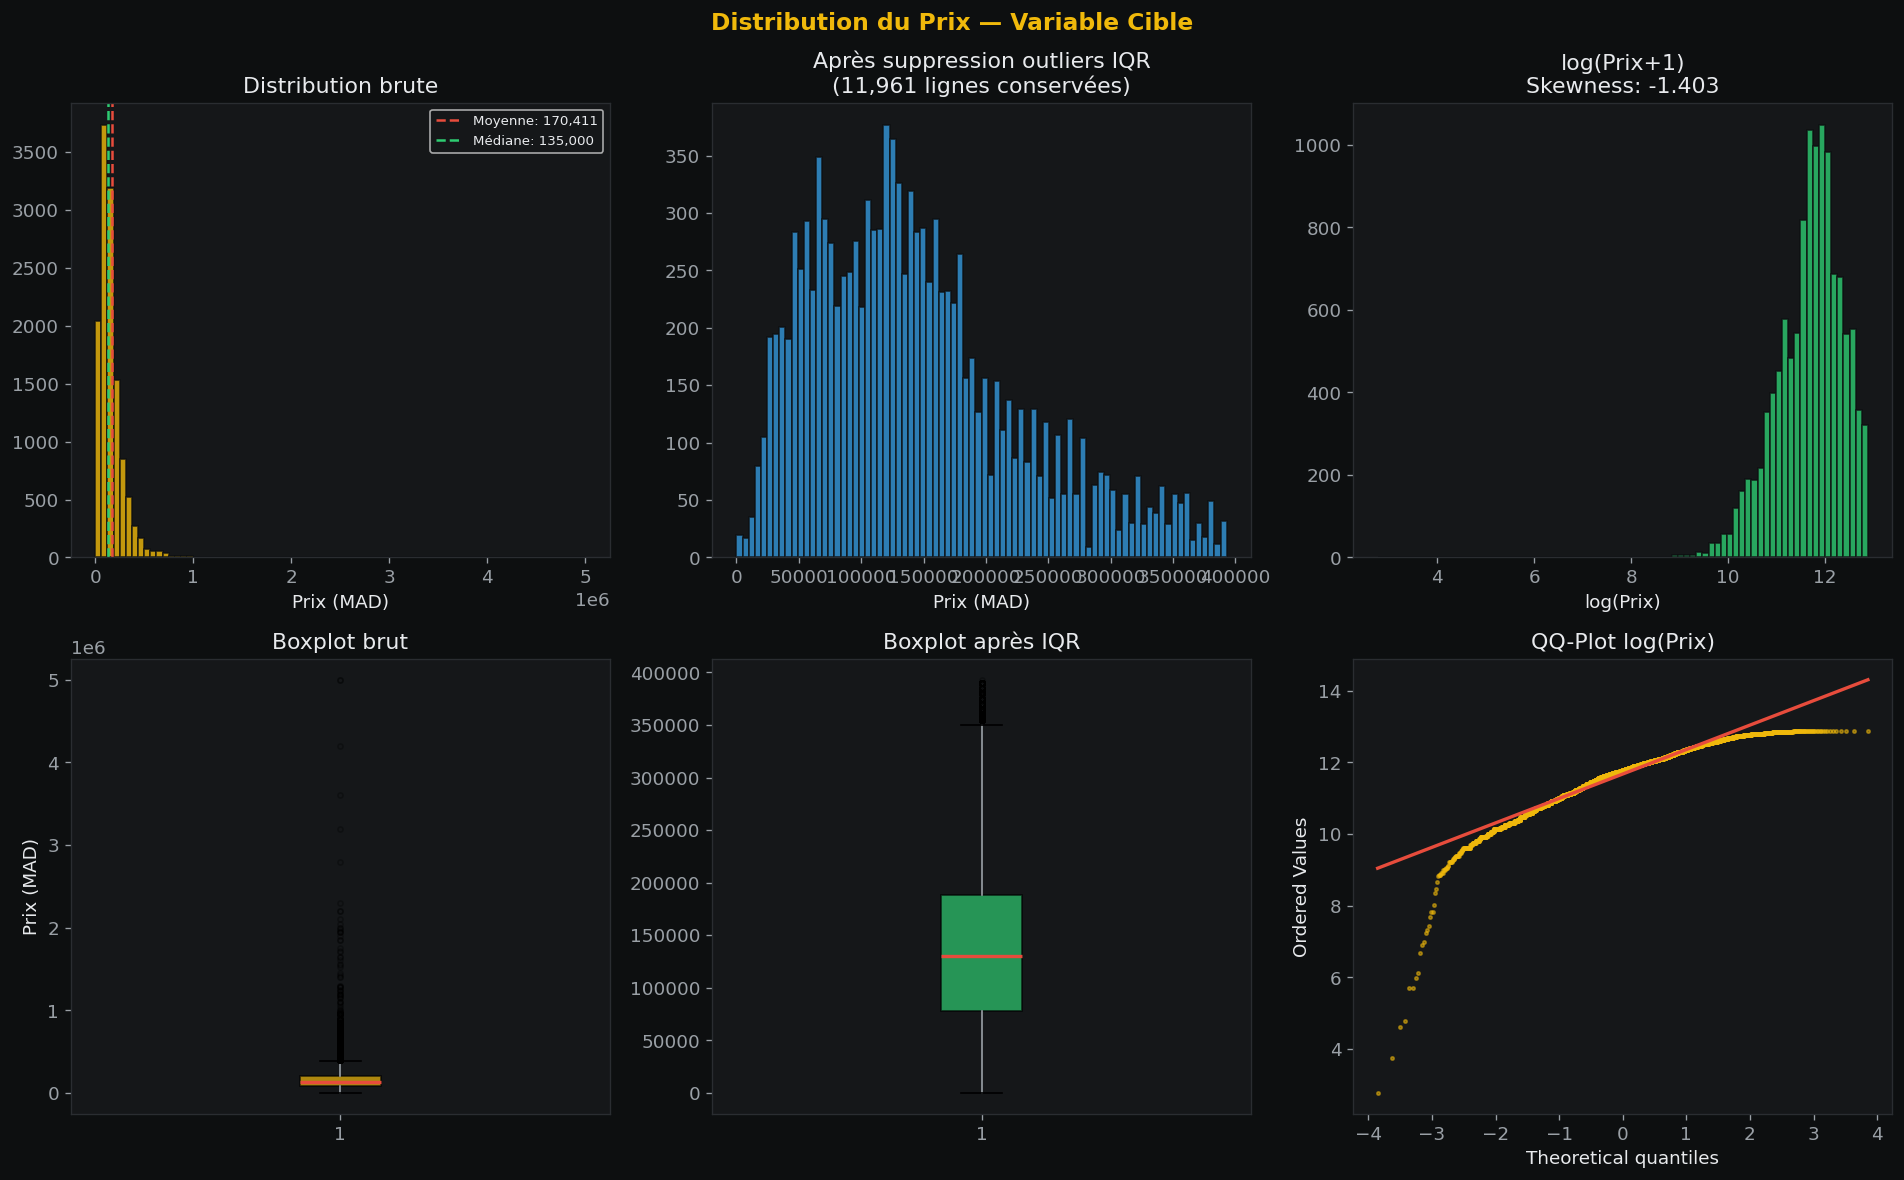

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribution du Prix — Variable Cible", fontsize=14, color=GOLD, fontweight='bold')

prix = d['Prix'].dropna()

# 1. Histogramme brut
axes[0,0].hist(prix, bins=80, color=GOLD, alpha=0.8, edgecolor='#0d0f10')
axes[0,0].set_title("Distribution brute")
axes[0,0].set_xlabel("Prix (MAD)")
axes[0,0].axvline(prix.mean(),   color=RED,   linestyle='--', linewidth=1.5, label=f'Moyenne: {prix.mean():,.0f}')
axes[0,0].axvline(prix.median(), color=GREEN, linestyle='--', linewidth=1.5, label=f'Médiane: {prix.median():,.0f}')
axes[0,0].legend(fontsize=8)

# 2. Après suppression outliers IQR
Q1, Q3 = prix.quantile(0.25), prix.quantile(0.75)
IQR = Q3 - Q1
prix_clean = prix[(prix >= Q1 - 1.5*IQR) & (prix <= Q3 + 1.5*IQR)]
axes[0,1].hist(prix_clean, bins=80, color=BLUE, alpha=0.8, edgecolor='#0d0f10')
axes[0,1].set_title(f"Après suppression outliers IQR\n({len(prix_clean):,} lignes conservées)")
axes[0,1].set_xlabel("Prix (MAD)")

# 3. Log-transformation
axes[0,2].hist(np.log1p(prix_clean), bins=80, color=GREEN, alpha=0.8, edgecolor='#0d0f10')
axes[0,2].set_title(f"log(Prix+1)\nSkewness: {np.log1p(prix_clean).skew():.3f}")
axes[0,2].set_xlabel("log(Prix)")

# 4. Boxplot brut
bp1 = axes[1,0].boxplot(prix.dropna(), vert=True, patch_artist=True,
    boxprops=dict(facecolor=GOLD, alpha=0.7),
    medianprops=dict(color=RED, linewidth=2),
    whiskerprops=dict(color='#9aa0a6'),
    flierprops=dict(marker='o', color=RED, alpha=0.3, markersize=3))
axes[1,0].set_title("Boxplot brut")
axes[1,0].set_ylabel("Prix (MAD)")

# 5. Boxplot après IQR
bp2 = axes[1,1].boxplot(prix_clean, vert=True, patch_artist=True,
    boxprops=dict(facecolor=GREEN, alpha=0.7),
    medianprops=dict(color=RED, linewidth=2),
    whiskerprops=dict(color='#9aa0a6'),
    flierprops=dict(marker='o', color=RED, alpha=0.3, markersize=3))
axes[1,1].set_title("Boxplot après IQR")

# 6. QQ-Plot
stats.probplot(np.log1p(prix_clean), dist="norm", plot=axes[1,2])
axes[1,2].set_title("QQ-Plot log(Prix)")
axes[1,2].get_lines()[0].set(color=GOLD, markersize=2, alpha=0.5)
axes[1,2].get_lines()[1].set(color=RED, linewidth=2)

print(f"Prix brut   — Skewness: {prix.skew():.3f} | Min: {prix.min():,.0f} | Max: {prix.max():,.0f}")
print(f"Prix clean  — Skewness: {prix_clean.skew():.3f} | Min: {prix_clean.min():,.0f} | Max: {prix_clean.max():,.0f}")
print(f"log(Prix)   — Skewness: {np.log1p(prix_clean).skew():.3f}")
print(f"Outliers supprimés : {len(prix) - len(prix_clean):,} ({(len(prix)-len(prix_clean))/len(prix)*100:.1f}%)")

plt.tight_layout()
plt.savefig('eda_02_prix_distribution.png', bbox_inches='tight', facecolor='#0d0f10')
plt.show()


## 6. Détection des outliers — toutes colonnes numériques

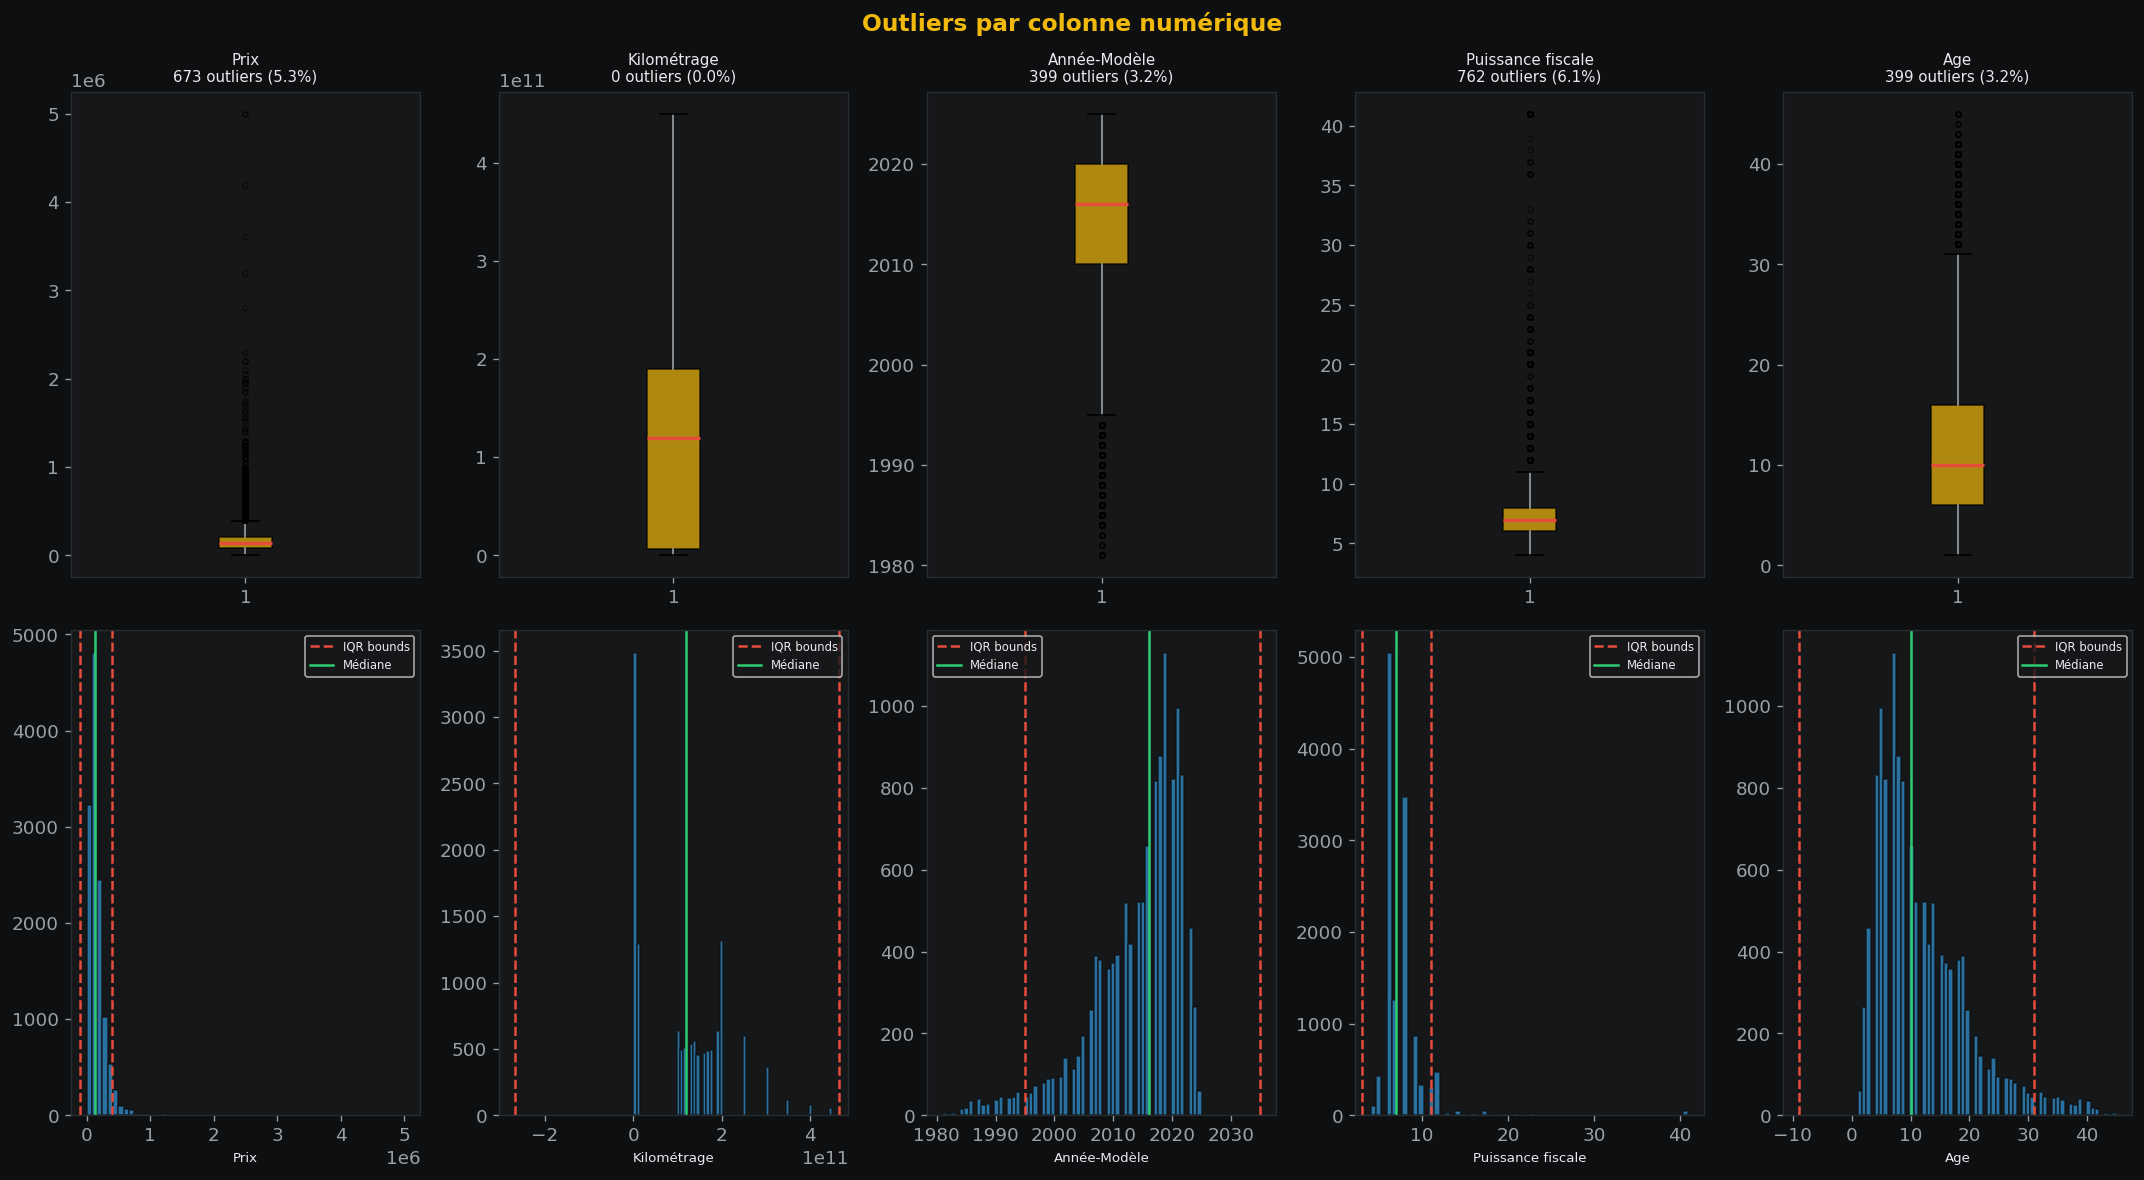


=== RÉSUMÉ OUTLIERS ===
          Colonne  N outliers  % outliers    Min          Max       IQR_low     IQR_high
             Prix         673        5.33   15.0 5.000000e+06 -1.055000e+05 3.945000e+05
      Kilométrage           0        0.00 4999.0 4.500005e+11 -2.687501e+11 4.652504e+11
     Année-Modèle         399        3.18 1981.0 2.025000e+03  1.995000e+03 2.035000e+03
Puissance fiscale         762        6.06    4.0 4.100000e+01  3.000000e+00 1.100000e+01
              Age         399        3.18    1.0 4.500000e+01 -9.000000e+00 3.100000e+01


In [7]:
cols_num = ['Prix', 'Kilométrage', 'Année-Modèle', 'Puissance fiscale', 'Age']

fig, axes = plt.subplots(2, len(cols_num), figsize=(18, 10))
fig.suptitle("Outliers par colonne numérique", fontsize=14, color=GOLD, fontweight='bold')

outlier_stats = []
for i, col in enumerate(cols_num):
    serie = d[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((serie < lb) | (serie > ub)).sum()
    pct   = n_out / len(serie) * 100
    outlier_stats.append({'Colonne': col, 'N outliers': n_out, '% outliers': round(pct,2),
                          'Min': serie.min(), 'Max': serie.max(), 'IQR_low': round(lb,1), 'IQR_high': round(ub,1)})

    # Boxplot
    bp = axes[0,i].boxplot(serie, vert=True, patch_artist=True,
        boxprops=dict(facecolor=GOLD, alpha=0.7),
        medianprops=dict(color=RED, linewidth=2),
        whiskerprops=dict(color='#9aa0a6'),
        flierprops=dict(marker='o', color=RED, alpha=0.4, markersize=3))
    axes[0,i].set_title(f"{col}\n{n_out:,} outliers ({pct:.1f}%)", fontsize=9)

    # Histogramme avec zones IQR
    axes[1,i].hist(serie, bins=60, color=BLUE, alpha=0.7, edgecolor='#0d0f10')
    axes[1,i].axvline(lb, color=RED,  linestyle='--', linewidth=1.5, label='IQR bounds')
    axes[1,i].axvline(ub, color=RED,  linestyle='--', linewidth=1.5)
    axes[1,i].axvline(serie.median(), color=GREEN, linewidth=1.5, label='Médiane')
    axes[1,i].set_xlabel(col, fontsize=8)
    axes[1,i].legend(fontsize=7)

plt.tight_layout()
plt.savefig('eda_03_outliers.png', bbox_inches='tight', facecolor='#0d0f10')
plt.show()

print("\n=== RÉSUMÉ OUTLIERS ===")
print(pd.DataFrame(outlier_stats).to_string(index=False))


## 7. Matrice de corrélation

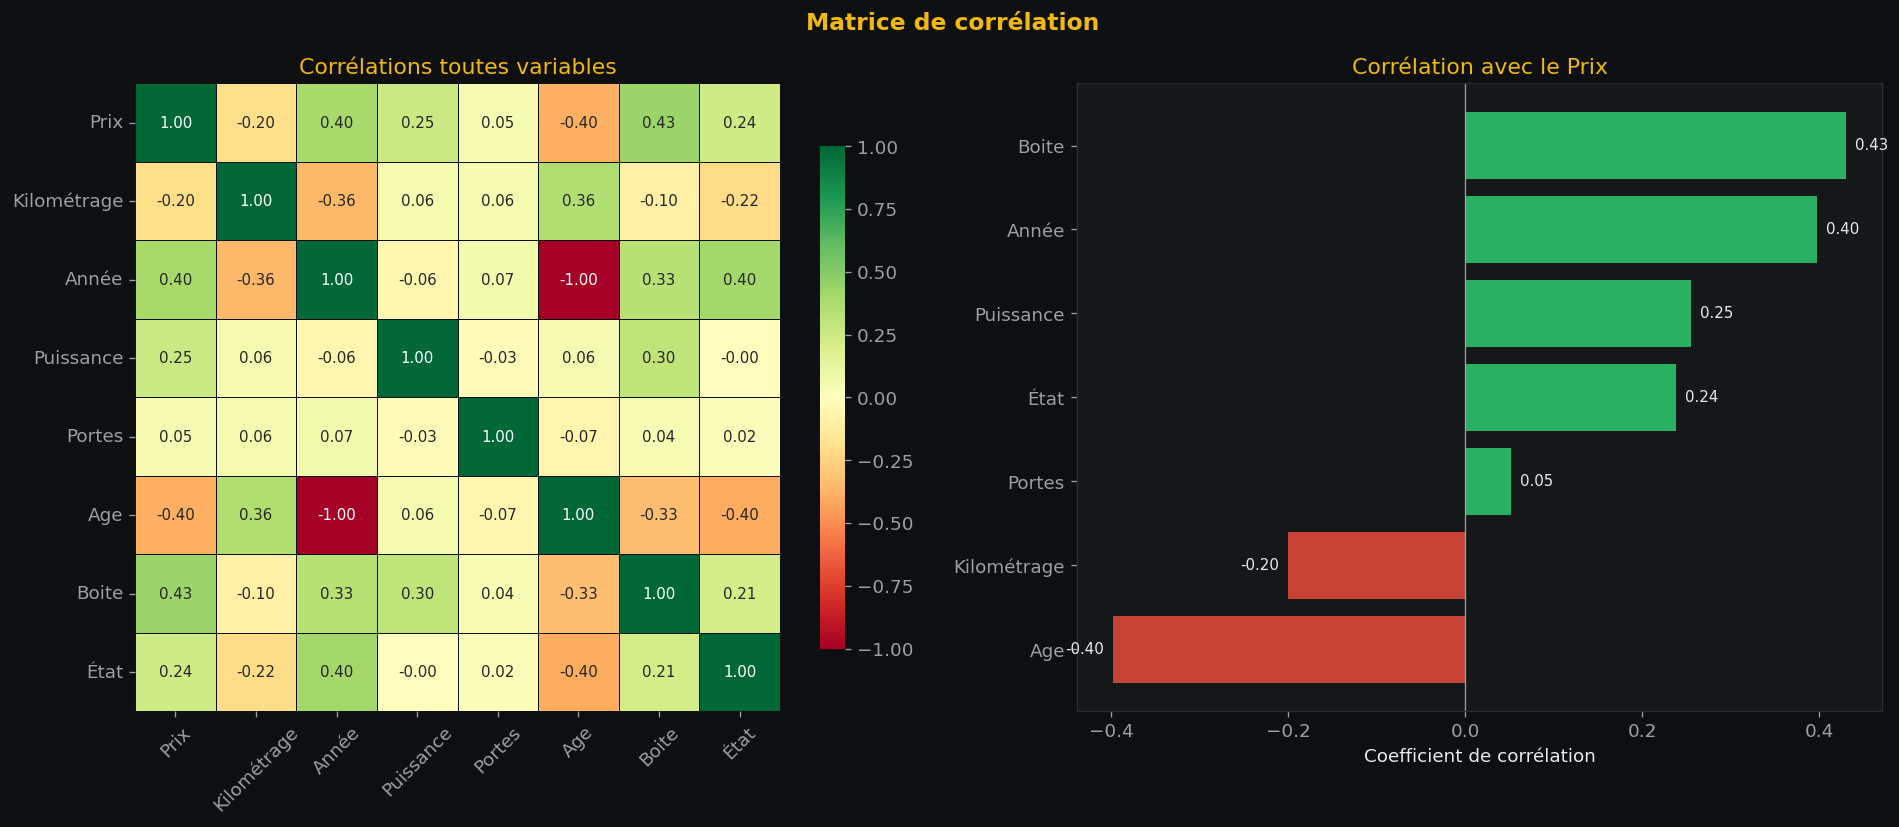


=== CORRÉLATIONS AVEC LE PRIX (triées) ===
Age           -0.398043
Kilométrage   -0.200849
Portes         0.051826
État           0.237991
Puissance      0.254698
Année          0.398043
Boite          0.430107


In [8]:
# Données propres pour la corrélation
df_corr = d[['Prix', 'Kilométrage', 'Année-Modèle', 'Puissance fiscale',
             'Nombre de portes', 'Age']].dropna()

# Encoder les colonnes catégorielles
d_enc = d.copy()
d_enc['Boite_num']     = d_enc['Boite de vitesses'].map({'Manuelle': 0, 'Automatique': 1})
d_enc['Etat_num']      = d_enc['État'].map({
    'Pour Pièces': 0, 'Endommagé': 1, 'Correct': 2,
    'Bon': 3, 'Très bon': 4, 'Excellent': 5, 'Neuf': 6
})
df_corr2 = d_enc[['Prix', 'Kilométrage', 'Année-Modèle', 'Puissance fiscale',
                   'Nombre de portes', 'Age', 'Boite_num', 'Etat_num']].dropna()
df_corr2.columns = ['Prix', 'Kilométrage', 'Année', 'Puissance', 'Portes', 'Age', 'Boite', 'État']

corr_matrix = df_corr2.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Matrice de corrélation", fontsize=14, color=GOLD, fontweight='bold')

# Heatmap complète
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 9}, linewidths=0.5, linecolor='#0d0f10',
            cbar_kws={'shrink': 0.8})
axes[0].set_title("Corrélations toutes variables", color=GOLD)
axes[0].tick_params(axis='x', rotation=45)

# Corrélation avec le Prix uniquement
corr_prix = corr_matrix['Prix'].drop('Prix').sort_values()
colors_bar = [RED if v < 0 else GREEN for v in corr_prix]
axes[1].barh(corr_prix.index, corr_prix.values, color=colors_bar, alpha=0.85)
axes[1].axvline(0, color='#9aa0a6', linewidth=0.8)
axes[1].set_title("Corrélation avec le Prix", color=GOLD)
axes[1].set_xlabel("Coefficient de corrélation")
for i, v in enumerate(corr_prix.values):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i,
                 f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right',
                 color='#e8eaed', fontsize=9)

plt.tight_layout()
plt.savefig('eda_04_correlations.png', bbox_inches='tight', facecolor='#0d0f10')
plt.show()

print("\n=== CORRÉLATIONS AVEC LE PRIX (triées) ===")
print(corr_prix.to_string())


## 8. Relations Prix vs variables numériques

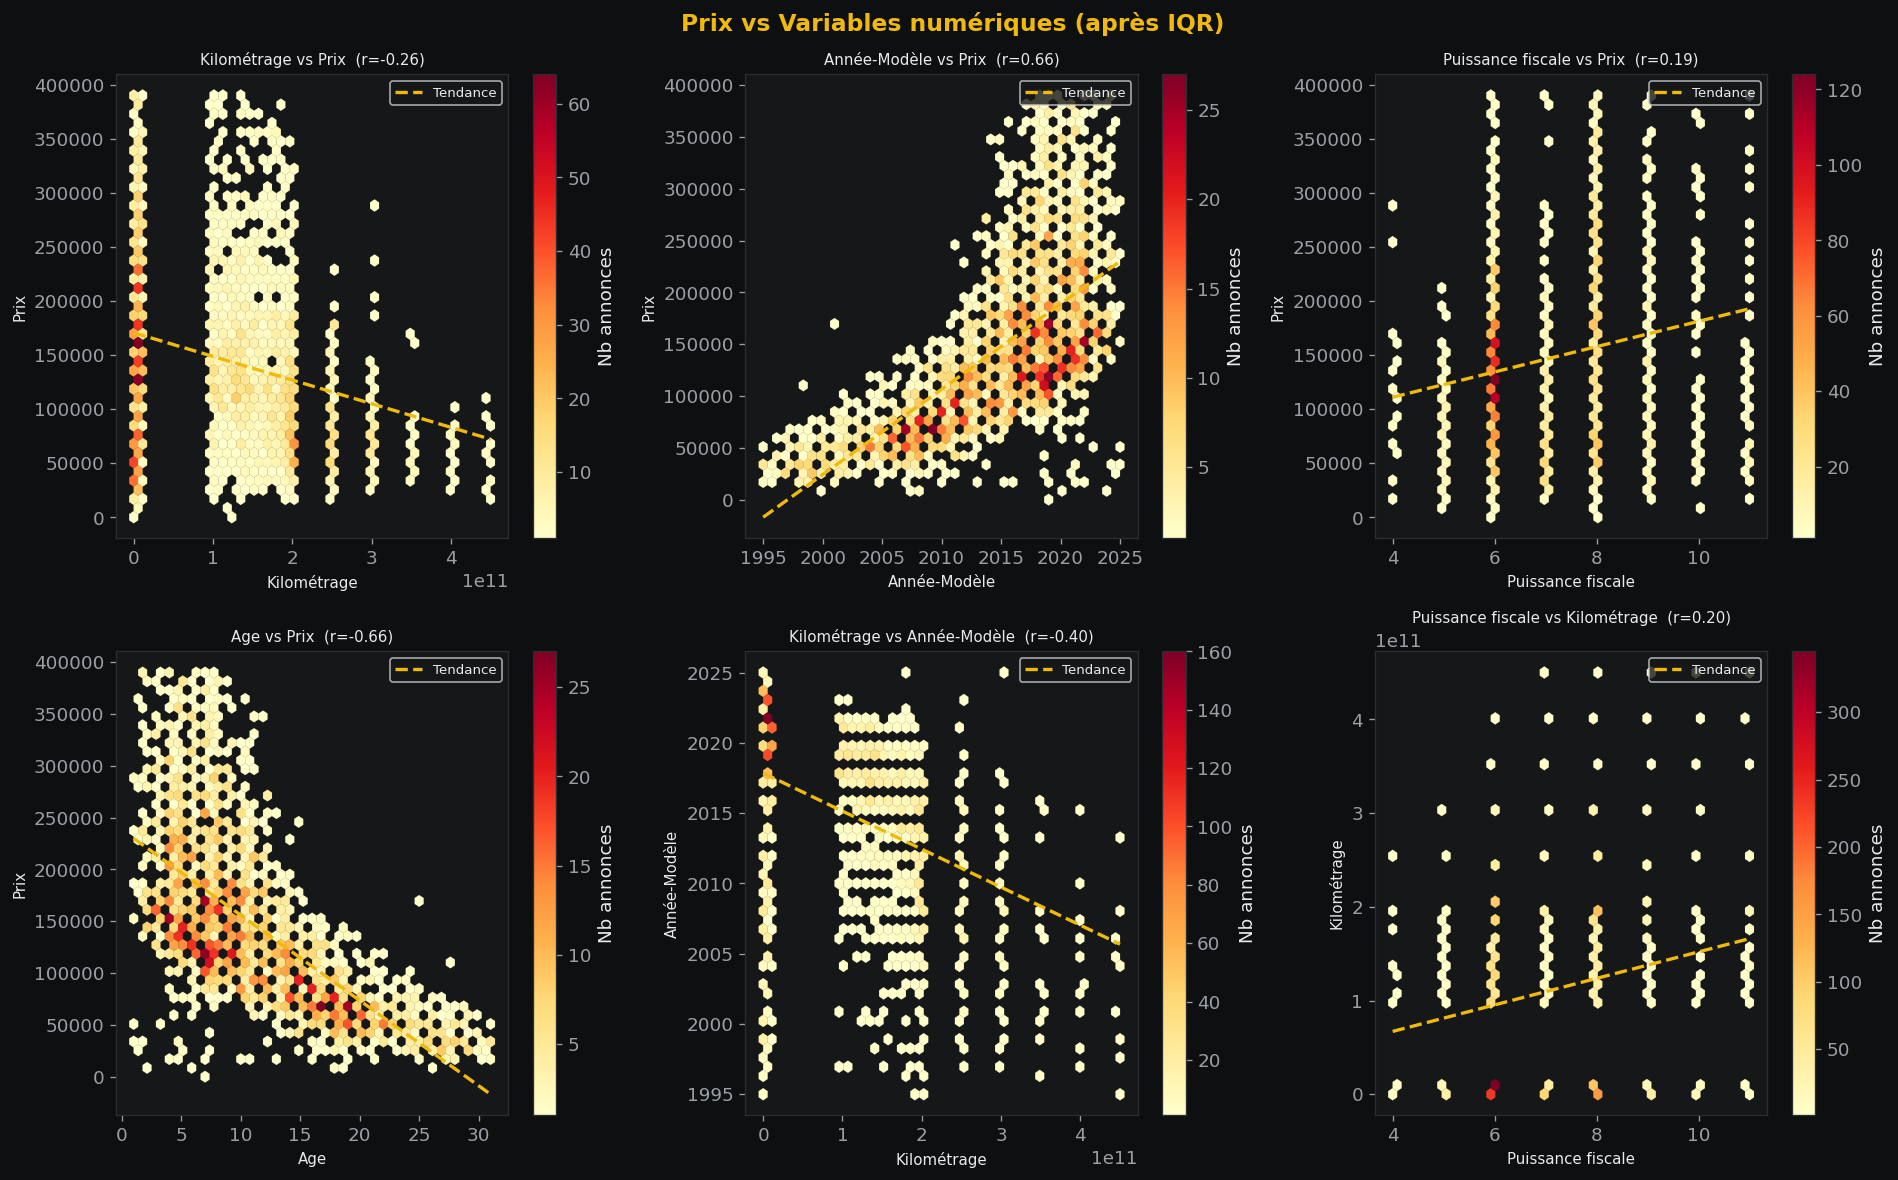

In [9]:
# Données après IQR
d_clean = d.copy()
for col in ['Prix', 'Kilométrage', 'Année-Modèle', 'Puissance fiscale']:
    Q1, Q3 = d_clean[col].quantile(0.25), d_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    d_clean = d_clean[(d_clean[col] >= Q1 - 1.5*IQR) & (d_clean[col] <= Q3 + 1.5*IQR)]

d_clean['Age'] = 2026 - d_clean['Année-Modèle']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Prix vs Variables numériques (après IQR)", fontsize=14, color=GOLD, fontweight='bold')

pairs = [
    ('Kilométrage',      'Prix'),
    ('Année-Modèle',     'Prix'),
    ('Puissance fiscale','Prix'),
    ('Age',              'Prix'),
    ('Kilométrage',      'Année-Modèle'),
    ('Puissance fiscale','Kilométrage'),
]

for idx, (x_col, y_col) in enumerate(pairs):
    ax = axes[idx // 3][idx % 3]
    sample = d_clean[[x_col, y_col]].dropna().sample(min(3000, len(d_clean)), random_state=42)

    # Densité via hexbin
    hb = ax.hexbin(sample[x_col], sample[y_col], gridsize=40,
                   cmap='YlOrRd', mincnt=1, linewidths=0.1)
    plt.colorbar(hb, ax=ax, label='Nb annonces')

    # Ligne de tendance
    z = np.polyfit(sample[x_col], sample[y_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[x_col].min(), sample[x_col].max(), 100)
    ax.plot(x_line, p(x_line), color=GOLD, linewidth=2, linestyle='--', label='Tendance')

    r = sample[[x_col, y_col]].corr().iloc[0,1]
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.set_title(f"{x_col} vs {y_col}  (r={r:.2f})", fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_05_scatter.png', bbox_inches='tight', facecolor='#0d0f10')
plt.show()


## 9. Analyse des variables catégorielles

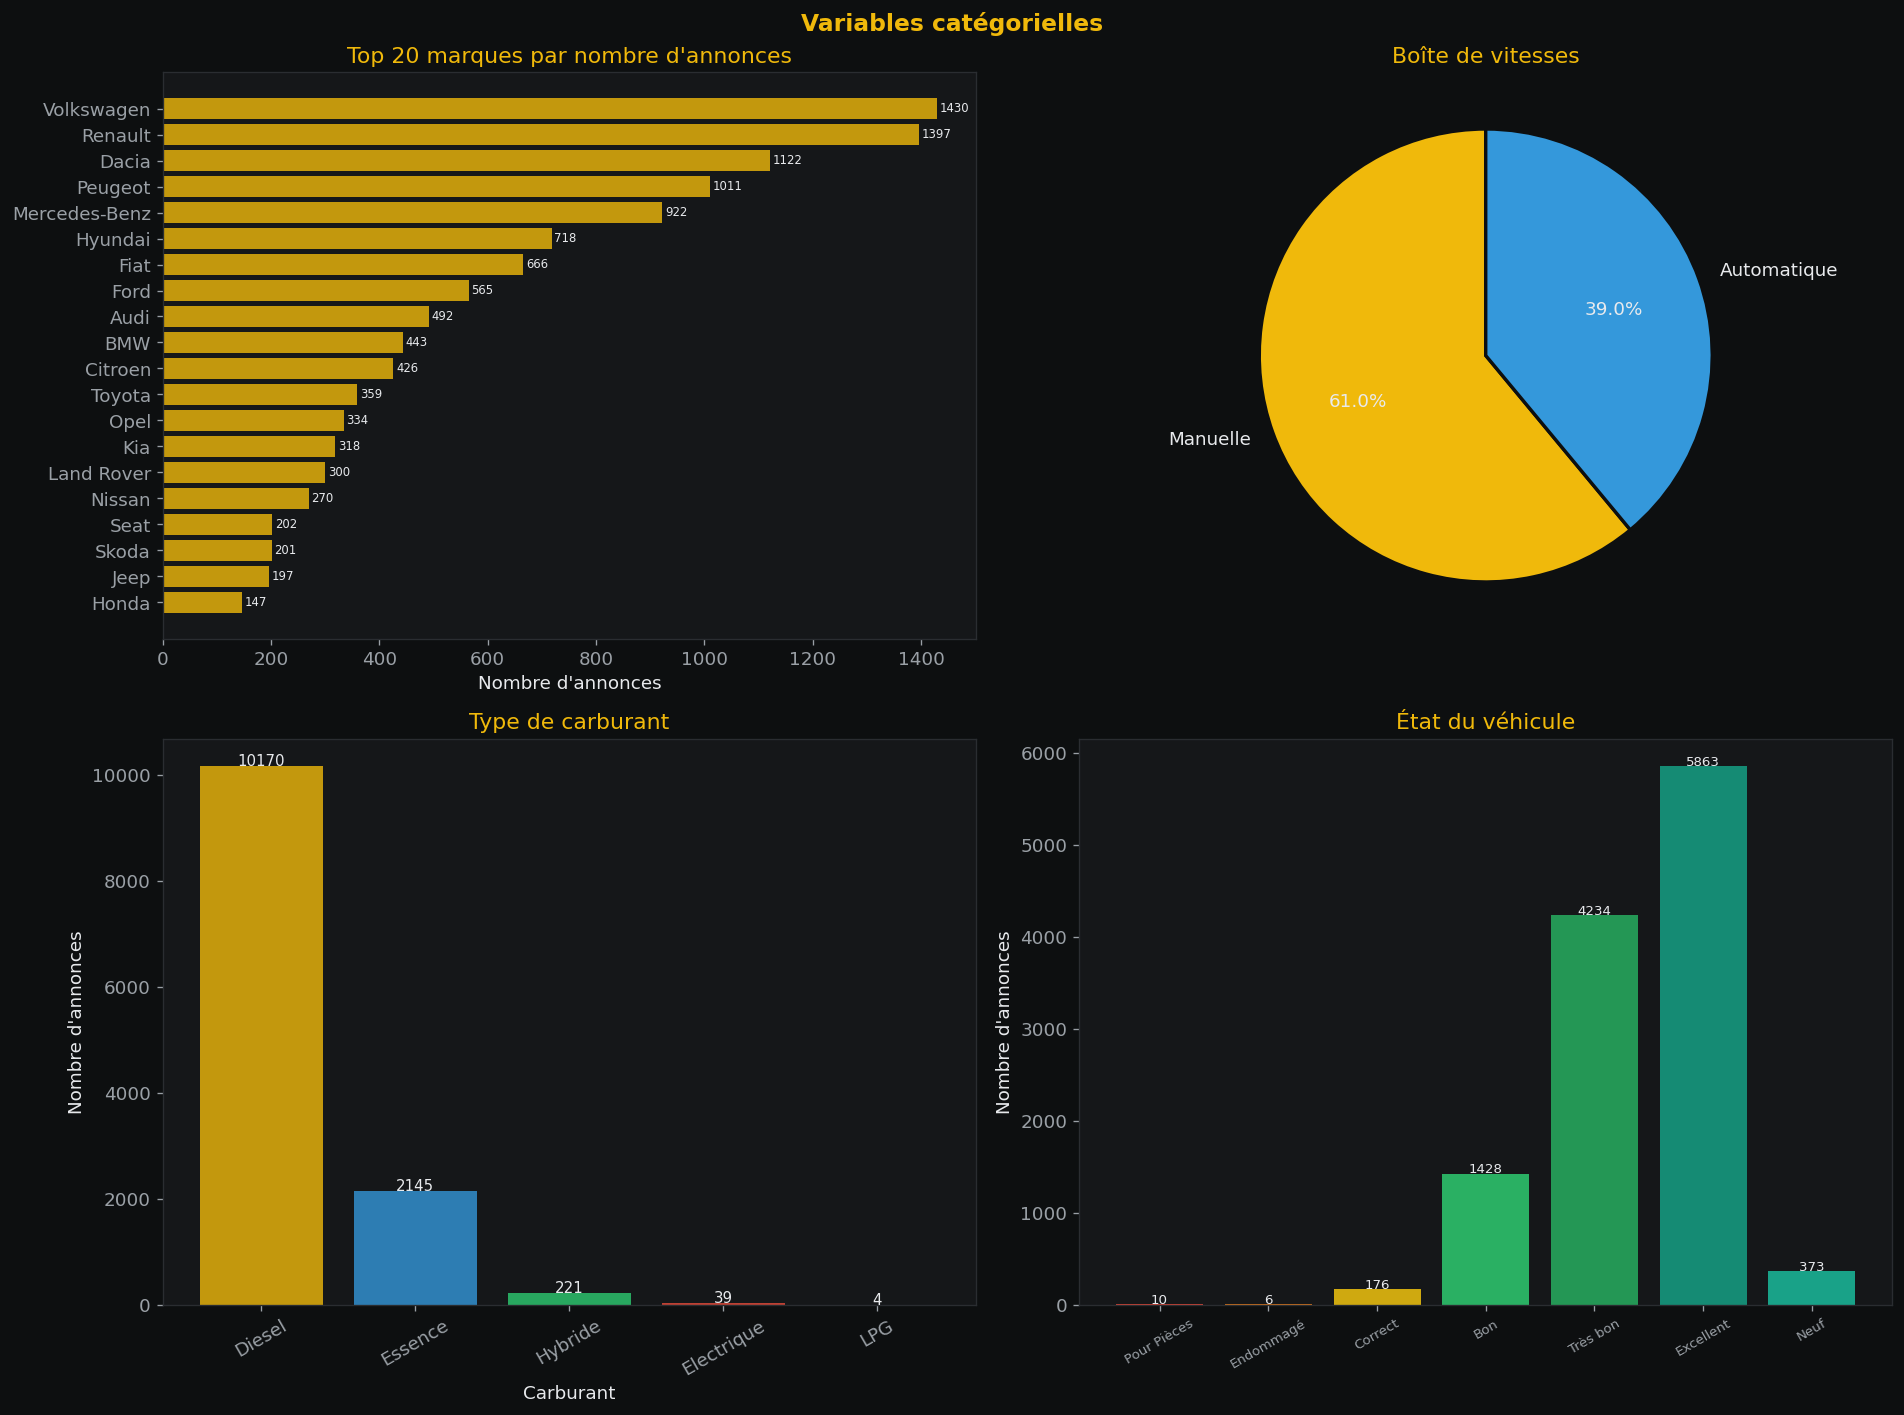

In [10]:
# Nombre d'annonces par Marque (Top 20)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Variables catégorielles", fontsize=14, color=GOLD, fontweight='bold')

# Top 20 marques par volume
top_marques = d['Marque'].value_counts().head(20)
axes[0,0].barh(top_marques.index[::-1], top_marques.values[::-1], color=GOLD, alpha=0.8)
axes[0,0].set_title("Top 20 marques par nombre d'annonces", color=GOLD)
axes[0,0].set_xlabel("Nombre d'annonces")
for i, v in enumerate(top_marques.values[::-1]):
    axes[0,0].text(v + 5, i, str(v), va='center', fontsize=7)

# Boite de vitesses
bv_counts = d['Boite de vitesses'].value_counts()
colors_pie = [GOLD, BLUE, GREEN, RED]
axes[0,1].pie(bv_counts.values, labels=bv_counts.index,
              colors=colors_pie[:len(bv_counts)],
              autopct='%1.1f%%', startangle=90,
              textprops={'color': '#e8eaed', 'fontsize': 11},
              wedgeprops={'edgecolor': '#0d0f10', 'linewidth': 2})
axes[0,1].set_title("Boîte de vitesses", color=GOLD)

# Carburant
carb_counts = d['Type de carburant'].value_counts()
axes[1,0].bar(carb_counts.index, carb_counts.values,
              color=[GOLD, BLUE, GREEN, RED, '#9b59b6'][:len(carb_counts)], alpha=0.8)
axes[1,0].set_title("Type de carburant", color=GOLD)
axes[1,0].set_xlabel("Carburant")
axes[1,0].set_ylabel("Nombre d'annonces")
axes[1,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(carb_counts.values):
    axes[1,0].text(i, v + 10, str(v), ha='center', fontsize=9)

# État
etat_order = ['Pour Pièces','Endommagé','Correct','Bon','Très bon','Excellent','Neuf']
etat_counts = d['État'].value_counts().reindex(etat_order).dropna()
color_etat = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60','#16a085','#1abc9c'][:len(etat_counts)]
axes[1,1].bar(range(len(etat_counts)), etat_counts.values, color=color_etat, alpha=0.85)
axes[1,1].set_xticks(range(len(etat_counts)))
axes[1,1].set_xticklabels(etat_counts.index, rotation=30, fontsize=8)
axes[1,1].set_title("État du véhicule", color=GOLD)
axes[1,1].set_ylabel("Nombre d'annonces")
for i, v in enumerate(etat_counts.values):
    axes[1,1].text(i, v + 5, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_06_categoriques.png', bbox_inches='tight', facecolor='#0d0f10')
plt.show()


## 10. Prix moyen par variable catégorielle

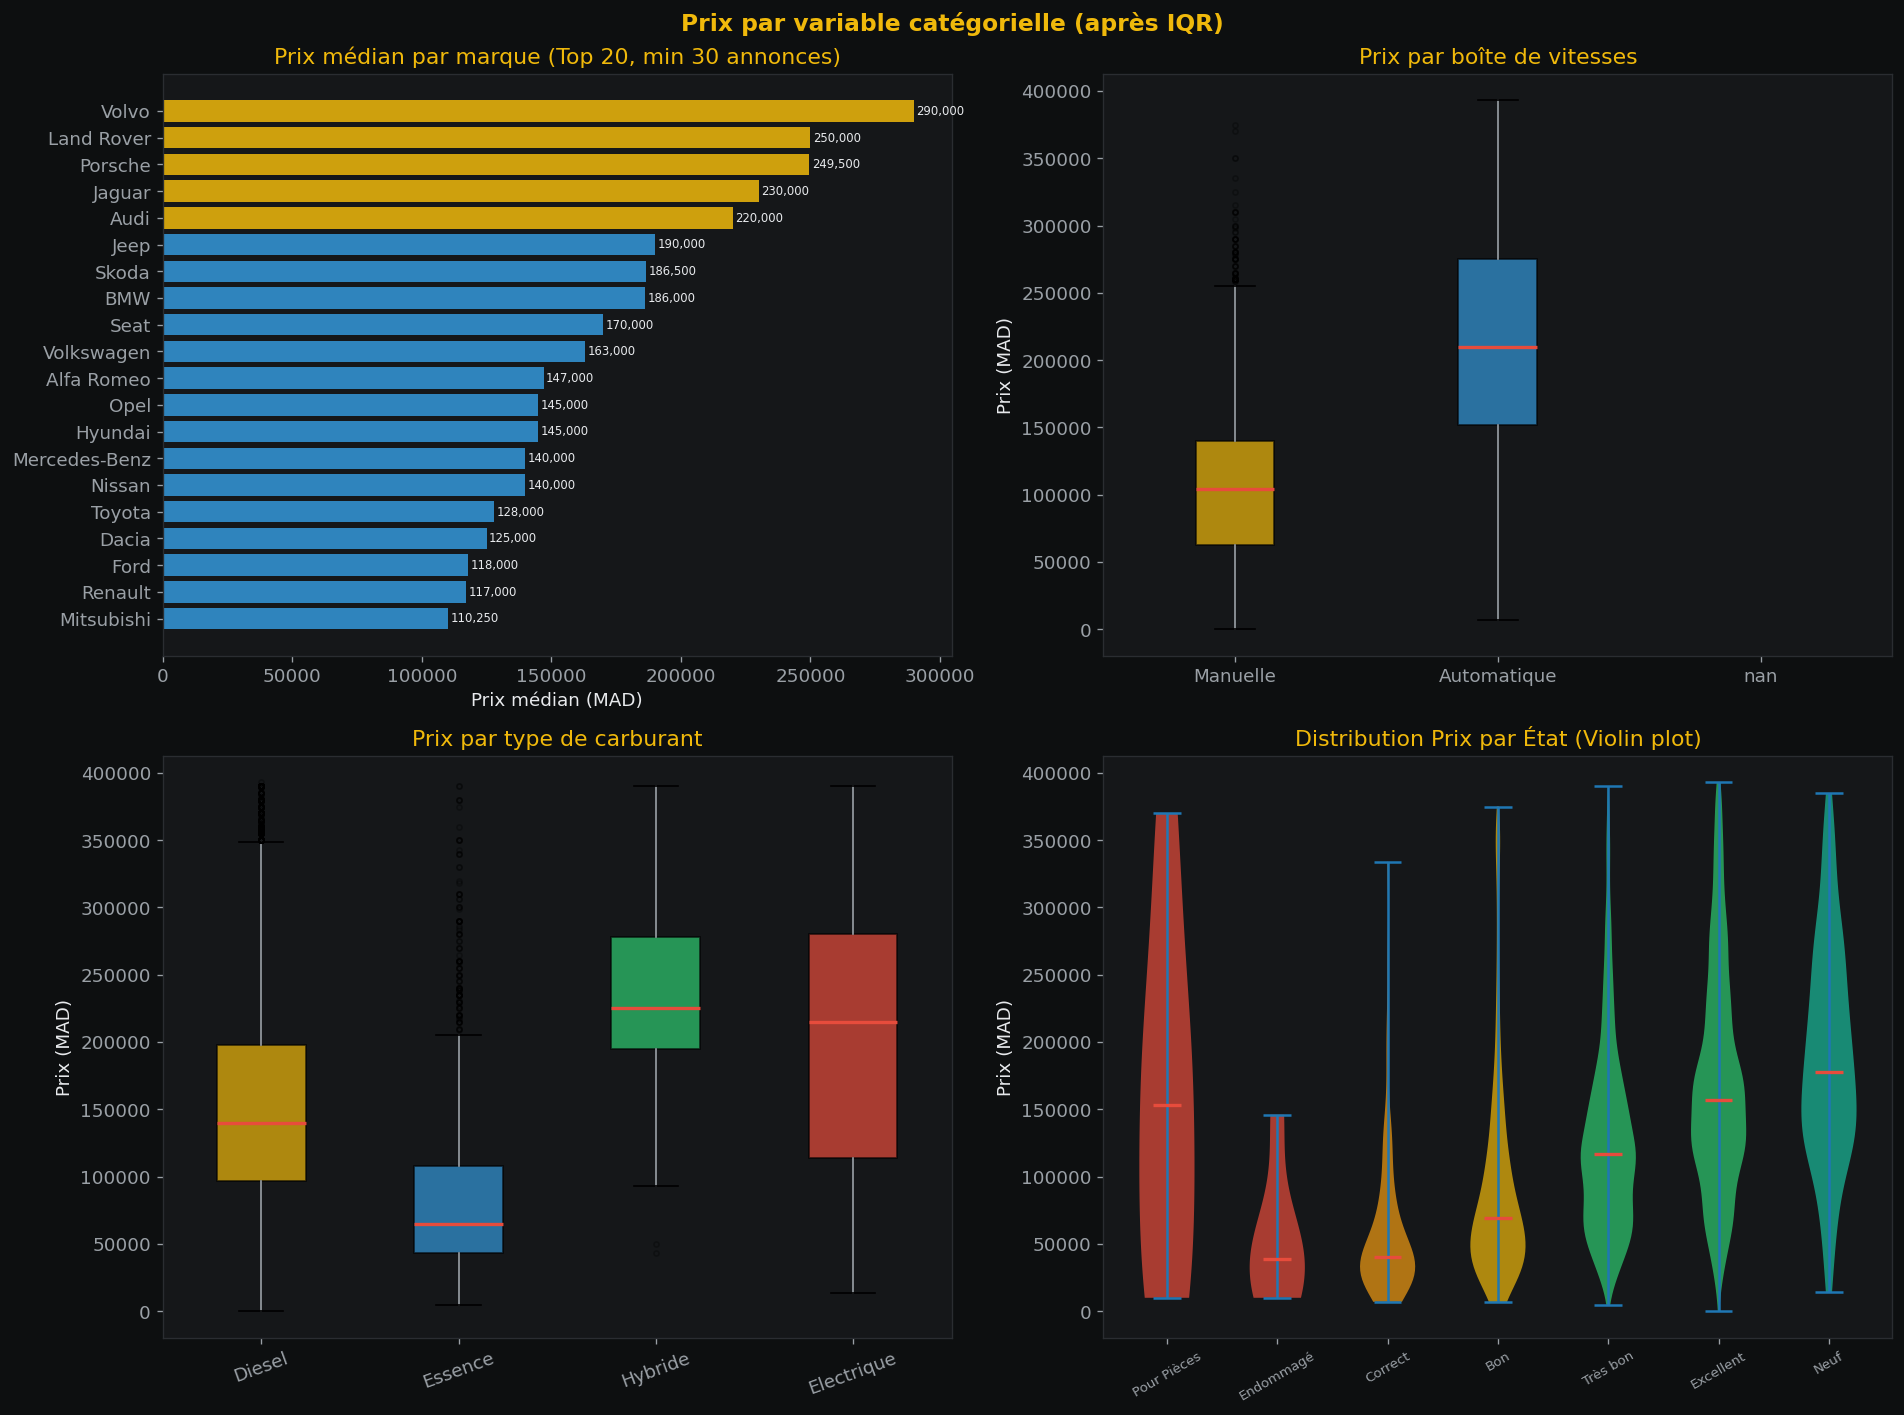

In [11]:
d_clean2 = d.copy()
Q1_p, Q3_p = d_clean2['Prix'].quantile(0.25), d_clean2['Prix'].quantile(0.75)
IQR_p = Q3_p - Q1_p
d_clean2 = d_clean2[(d_clean2['Prix'] >= Q1_p - 1.5*IQR_p) & (d_clean2['Prix'] <= Q3_p + 1.5*IQR_p)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Prix par variable catégorielle (après IQR)", fontsize=14, color=GOLD, fontweight='bold')

# Prix médian par marque (Top 20)
prix_marque = d_clean2.groupby('Marque')['Prix'].agg(['median','count'])
prix_marque = prix_marque[prix_marque['count'] >= 30].sort_values('median', ascending=False).head(20)
colors_m = [GOLD if i < 5 else BLUE for i in range(len(prix_marque))]
axes[0,0].barh(prix_marque.index[::-1], prix_marque['median'].values[::-1], color=colors_m[::-1], alpha=0.85)
axes[0,0].set_title("Prix médian par marque (Top 20, min 30 annonces)", color=GOLD)
axes[0,0].set_xlabel("Prix médian (MAD)")
for i, v in enumerate(prix_marque['median'].values[::-1]):
    axes[0,0].text(v + 1000, i, f'{v:,.0f}', va='center', fontsize=7)

# Boxplot Prix par Boite de vitesses
bv_data = [d_clean2[d_clean2['Boite de vitesses']==bv]['Prix'].dropna()
           for bv in d_clean2['Boite de vitesses'].unique()]
bv_labels = d_clean2['Boite de vitesses'].unique()
bp = axes[0,1].boxplot(bv_data, labels=bv_labels, patch_artist=True,
    medianprops=dict(color=RED, linewidth=2),
    whiskerprops=dict(color='#9aa0a6'),
    flierprops=dict(marker='o', color=RED, alpha=0.3, markersize=3))
for patch, color in zip(bp['boxes'], [GOLD, BLUE, GREEN, '#9b59b6']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0,1].set_title("Prix par boîte de vitesses", color=GOLD)
axes[0,1].set_ylabel("Prix (MAD)")

# Boxplot Prix par Carburant
carb_vals  = [c for c in d_clean2['Type de carburant'].value_counts().index if d_clean2[d_clean2['Type de carburant']==c]['Prix'].count() > 10]
carb_data  = [d_clean2[d_clean2['Type de carburant']==c]['Prix'].dropna() for c in carb_vals]
bp2 = axes[1,0].boxplot(carb_data, labels=carb_vals, patch_artist=True,
    medianprops=dict(color=RED, linewidth=2),
    whiskerprops=dict(color='#9aa0a6'),
    flierprops=dict(marker='o', color=RED, alpha=0.3, markersize=3))
for patch, color in zip(bp2['boxes'], [GOLD, BLUE, GREEN, RED, '#9b59b6']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1,0].set_title("Prix par type de carburant", color=GOLD)
axes[1,0].set_ylabel("Prix (MAD)")
axes[1,0].tick_params(axis='x', rotation=20)

# Violin plot Prix par État
etat_order2 = [e for e in ['Pour Pièces','Endommagé','Correct','Bon','Très bon','Excellent','Neuf']
               if e in d_clean2['État'].values]
etat_data2 = [d_clean2[d_clean2['État']==e]['Prix'].dropna() for e in etat_order2]
vp = axes[1,1].violinplot(etat_data2, positions=range(len(etat_order2)), showmedians=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor([RED,RED,'#f39c12',GOLD,GREEN,GREEN,'#1abc9c'][i % 7])
    body.set_alpha(0.7)
vp['cmedians'].set_color(RED); vp['cmedians'].set_linewidth(2)
axes[1,1].set_xticks(range(len(etat_order2)))
axes[1,1].set_xticklabels(etat_order2, rotation=30, fontsize=8)
axes[1,1].set_title("Distribution Prix par État (Violin plot)", color=GOLD)
axes[1,1].set_ylabel("Prix (MAD)")

plt.tight_layout()
plt.savefig('eda_07_prix_par_categorie.png', bbox_inches='tight', facecolor='#0d0f10')
plt.show()


## 11. Évolution du prix et kilométrage selon l'année

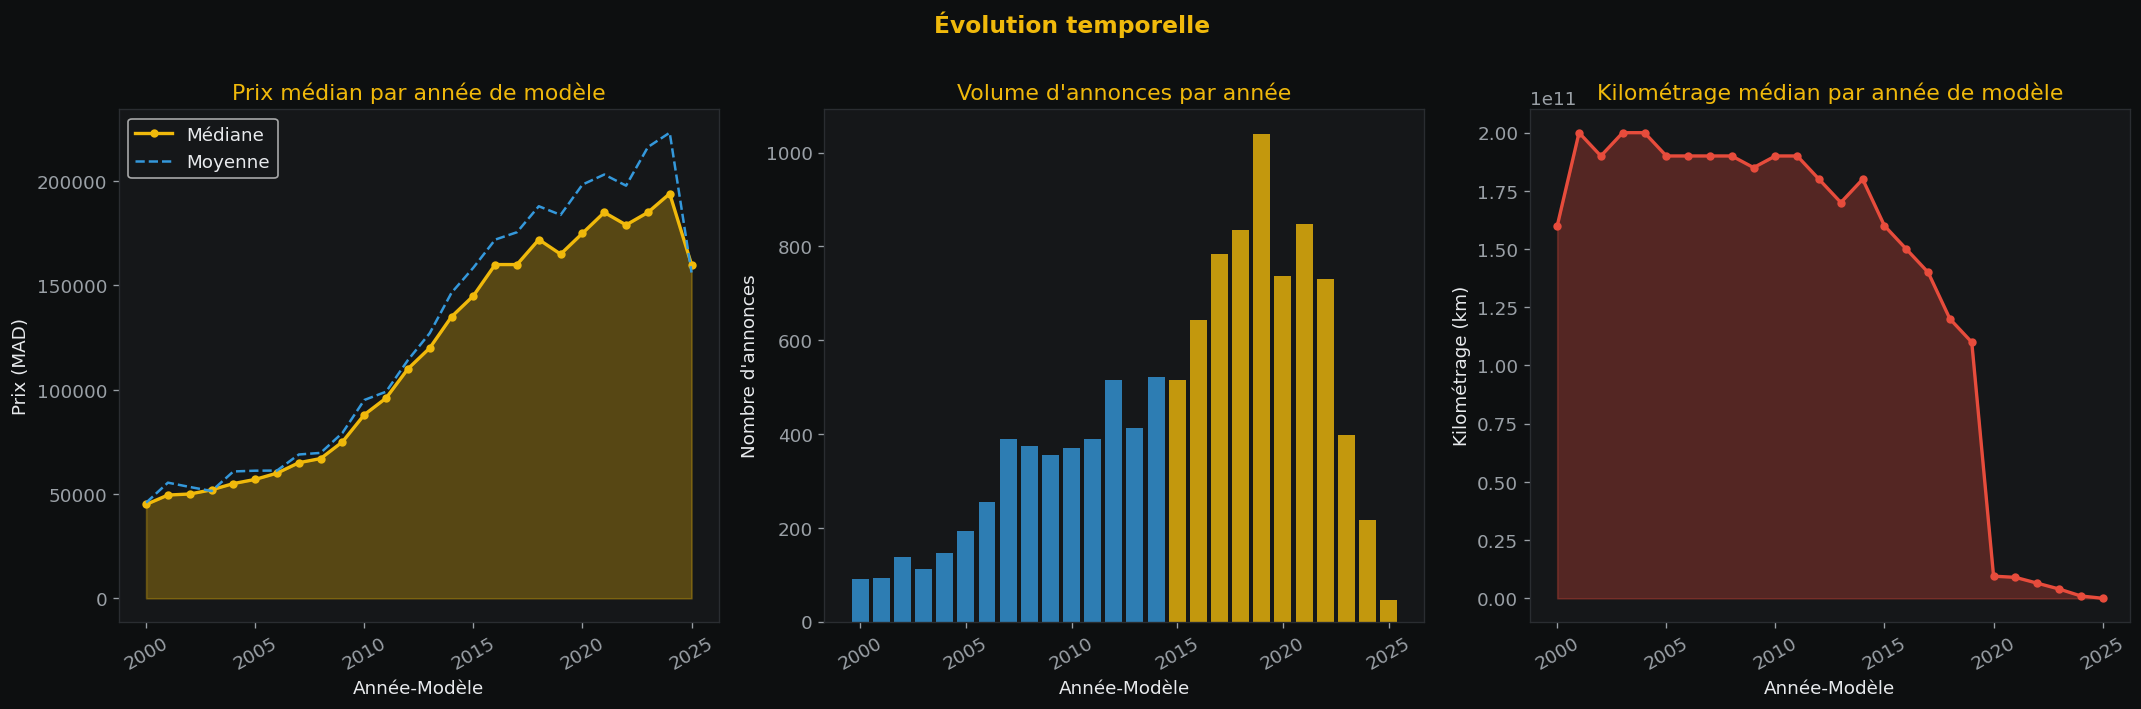

In [12]:
d_time = d_clean2.dropna(subset=['Année-Modèle','Prix','Kilométrage'])
d_time = d_time[(d_time['Année-Modèle'] >= 2000) & (d_time['Année-Modèle'] <= 2025)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Évolution temporelle", fontsize=14, color=GOLD, fontweight='bold')

# Prix médian par année
prix_annee = d_time.groupby('Année-Modèle')['Prix'].agg(['median','mean','count']).reset_index()
axes[0].fill_between(prix_annee['Année-Modèle'], prix_annee['median'], alpha=0.3, color=GOLD)
axes[0].plot(prix_annee['Année-Modèle'], prix_annee['median'], color=GOLD, linewidth=2, marker='o', markersize=4, label='Médiane')
axes[0].plot(prix_annee['Année-Modèle'], prix_annee['mean'],   color=BLUE, linewidth=1.5, linestyle='--', label='Moyenne')
axes[0].set_title("Prix médian par année de modèle", color=GOLD)
axes[0].set_xlabel("Année-Modèle"); axes[0].set_ylabel("Prix (MAD)")
axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)

# Volume d'annonces par année
axes[1].bar(prix_annee['Année-Modèle'], prix_annee['count'],
            color=[GOLD if y >= 2015 else BLUE for y in prix_annee['Année-Modèle']], alpha=0.8)
axes[1].set_title("Volume d'annonces par année", color=GOLD)
axes[1].set_xlabel("Année-Modèle"); axes[1].set_ylabel("Nombre d'annonces")
axes[1].tick_params(axis='x', rotation=30)

# Kilométrage médian par année
km_annee = d_time.groupby('Année-Modèle')['Kilométrage'].median().reset_index()
axes[2].fill_between(km_annee['Année-Modèle'], km_annee['Kilométrage'], alpha=0.3, color=RED)
axes[2].plot(km_annee['Année-Modèle'], km_annee['Kilométrage'], color=RED, linewidth=2, marker='o', markersize=4)
axes[2].set_title("Kilométrage médian par année de modèle", color=GOLD)
axes[2].set_xlabel("Année-Modèle"); axes[2].set_ylabel("Kilométrage (km)")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_08_temporel.png', bbox_inches='tight', facecolor='#0d0f10')
plt.show()


## 12. Analyse des équipements

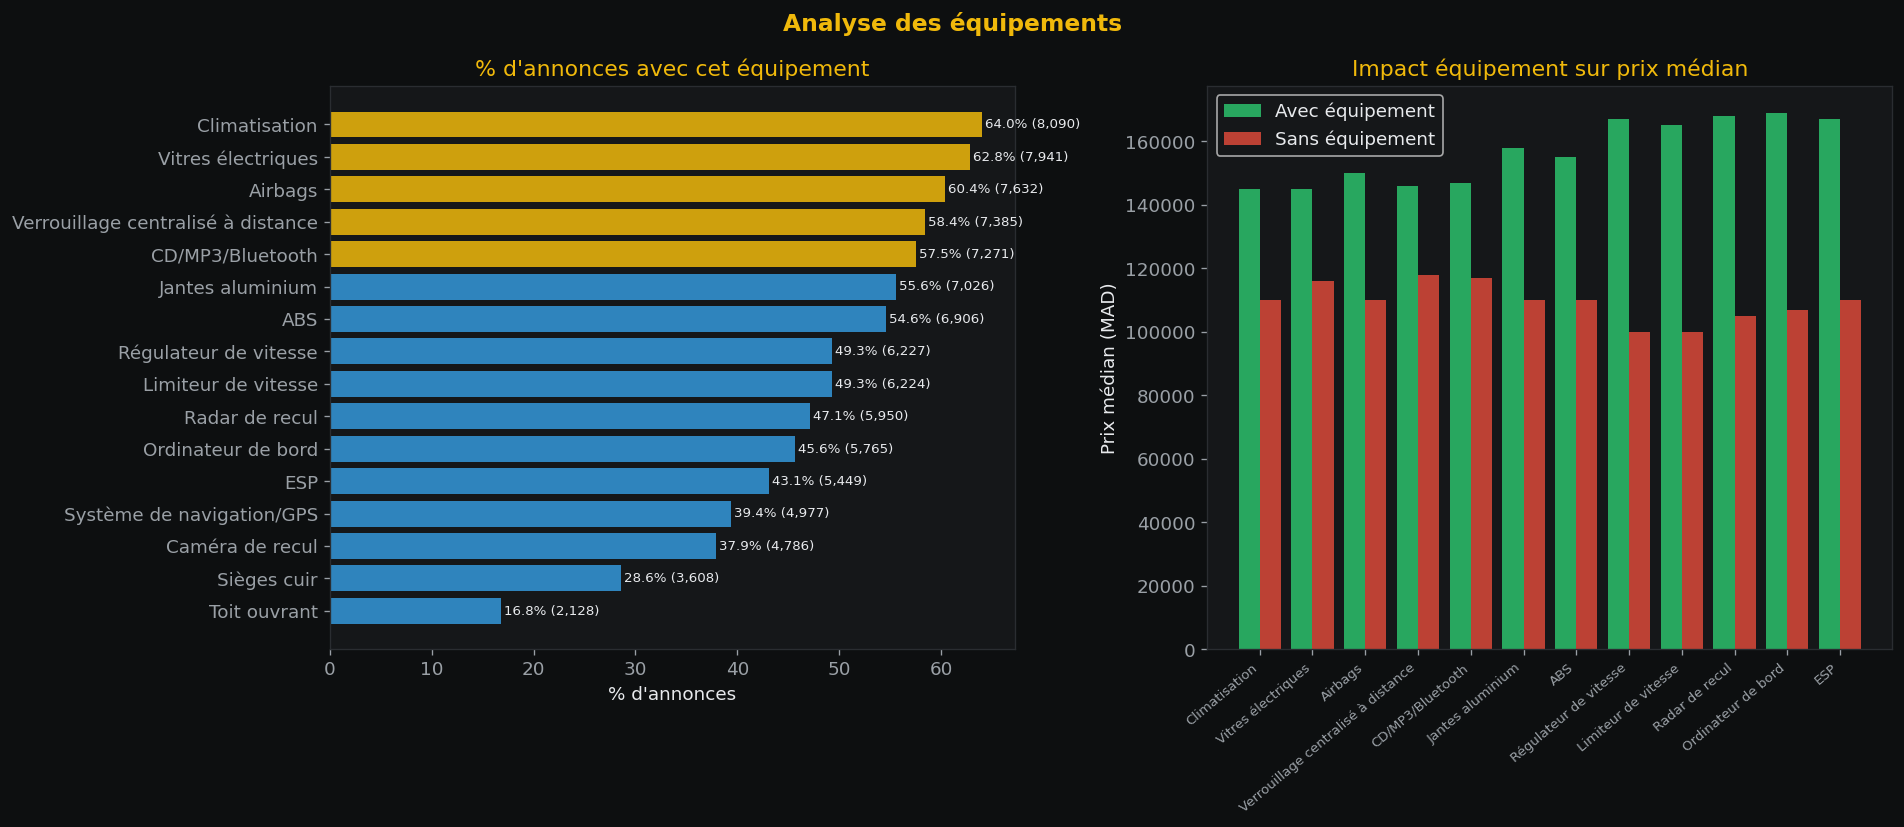


=== FRÉQUENCE DES ÉQUIPEMENTS ===
                        Équipement  Count  Pct
                     Climatisation   8090 64.0
                Vitres électriques   7941 62.8
                           Airbags   7632 60.4
Verrouillage centralisé à distance   7385 58.4
                  CD/MP3/Bluetooth   7271 57.5
                  Jantes aluminium   7026 55.6
                               ABS   6906 54.6
             Régulateur de vitesse   6227 49.3
               Limiteur de vitesse   6224 49.3
                    Radar de recul   5950 47.1
                Ordinateur de bord   5765 45.6
                               ESP   5449 43.1
         Système de navigation/GPS   4977 39.4
                   Caméra de recul   4786 37.9
                       Sièges cuir   3608 28.6
                      Toit ouvrant   2128 16.8


In [13]:
# Parser les équipements
d['eq_list'] = d['Équipements'].apply(lambda x: eval(x) if isinstance(x, str) and x.startswith('[') else [])

# Fréquence de chaque équipement
from collections import Counter
all_eq = [eq for lst in d['eq_list'] for eq in lst]
eq_counts = Counter(all_eq)
eq_df = pd.DataFrame(eq_counts.items(), columns=['Équipement','Count']).sort_values('Count', ascending=False)
eq_df['Pct'] = (eq_df['Count'] / len(d) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Analyse des équipements", fontsize=14, color=GOLD, fontweight='bold')

# Fréquence
colors_eq = [GOLD if i < 5 else BLUE for i in range(len(eq_df))]
axes[0].barh(eq_df['Équipement'][::-1], eq_df['Pct'][::-1], color=colors_eq[::-1], alpha=0.85)
axes[0].set_title("% d'annonces avec cet équipement", color=GOLD)
axes[0].set_xlabel("% d'annonces")
for i, (v, c) in enumerate(zip(eq_df['Pct'][::-1], eq_df['Count'][::-1])):
    axes[0].text(v + 0.3, i, f'{v:.1f}% ({c:,})', va='center', fontsize=8)

# Impact sur le prix
prix_avec = {}
prix_sans = {}
for eq in eq_df['Équipement'][:12]:
    mask = d['eq_list'].apply(lambda x: eq in x)
    p_avec = d[mask]['Prix'].dropna()
    p_sans = d[~mask]['Prix'].dropna()
    if len(p_avec) > 20 and len(p_sans) > 20:
        prix_avec[eq] = p_avec.median()
        prix_sans[eq] = p_sans.median()

eq_labels = list(prix_avec.keys())
x = np.arange(len(eq_labels))
w = 0.4
axes[1].bar(x - w/2, [prix_avec[e] for e in eq_labels], w, label='Avec équipement', color=GREEN, alpha=0.8)
axes[1].bar(x + w/2, [prix_sans[e] for e in eq_labels], w, label='Sans équipement', color=RED, alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(eq_labels, rotation=40, ha='right', fontsize=8)
axes[1].set_title("Impact équipement sur prix médian", color=GOLD)
axes[1].set_ylabel("Prix médian (MAD)")
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_09_equipements.png', bbox_inches='tight', facecolor='#0d0f10')
plt.show()

print("\n=== FRÉQUENCE DES ÉQUIPEMENTS ===")
print(eq_df.to_string(index=False))


## 13. Tableau de bord récapitulatif

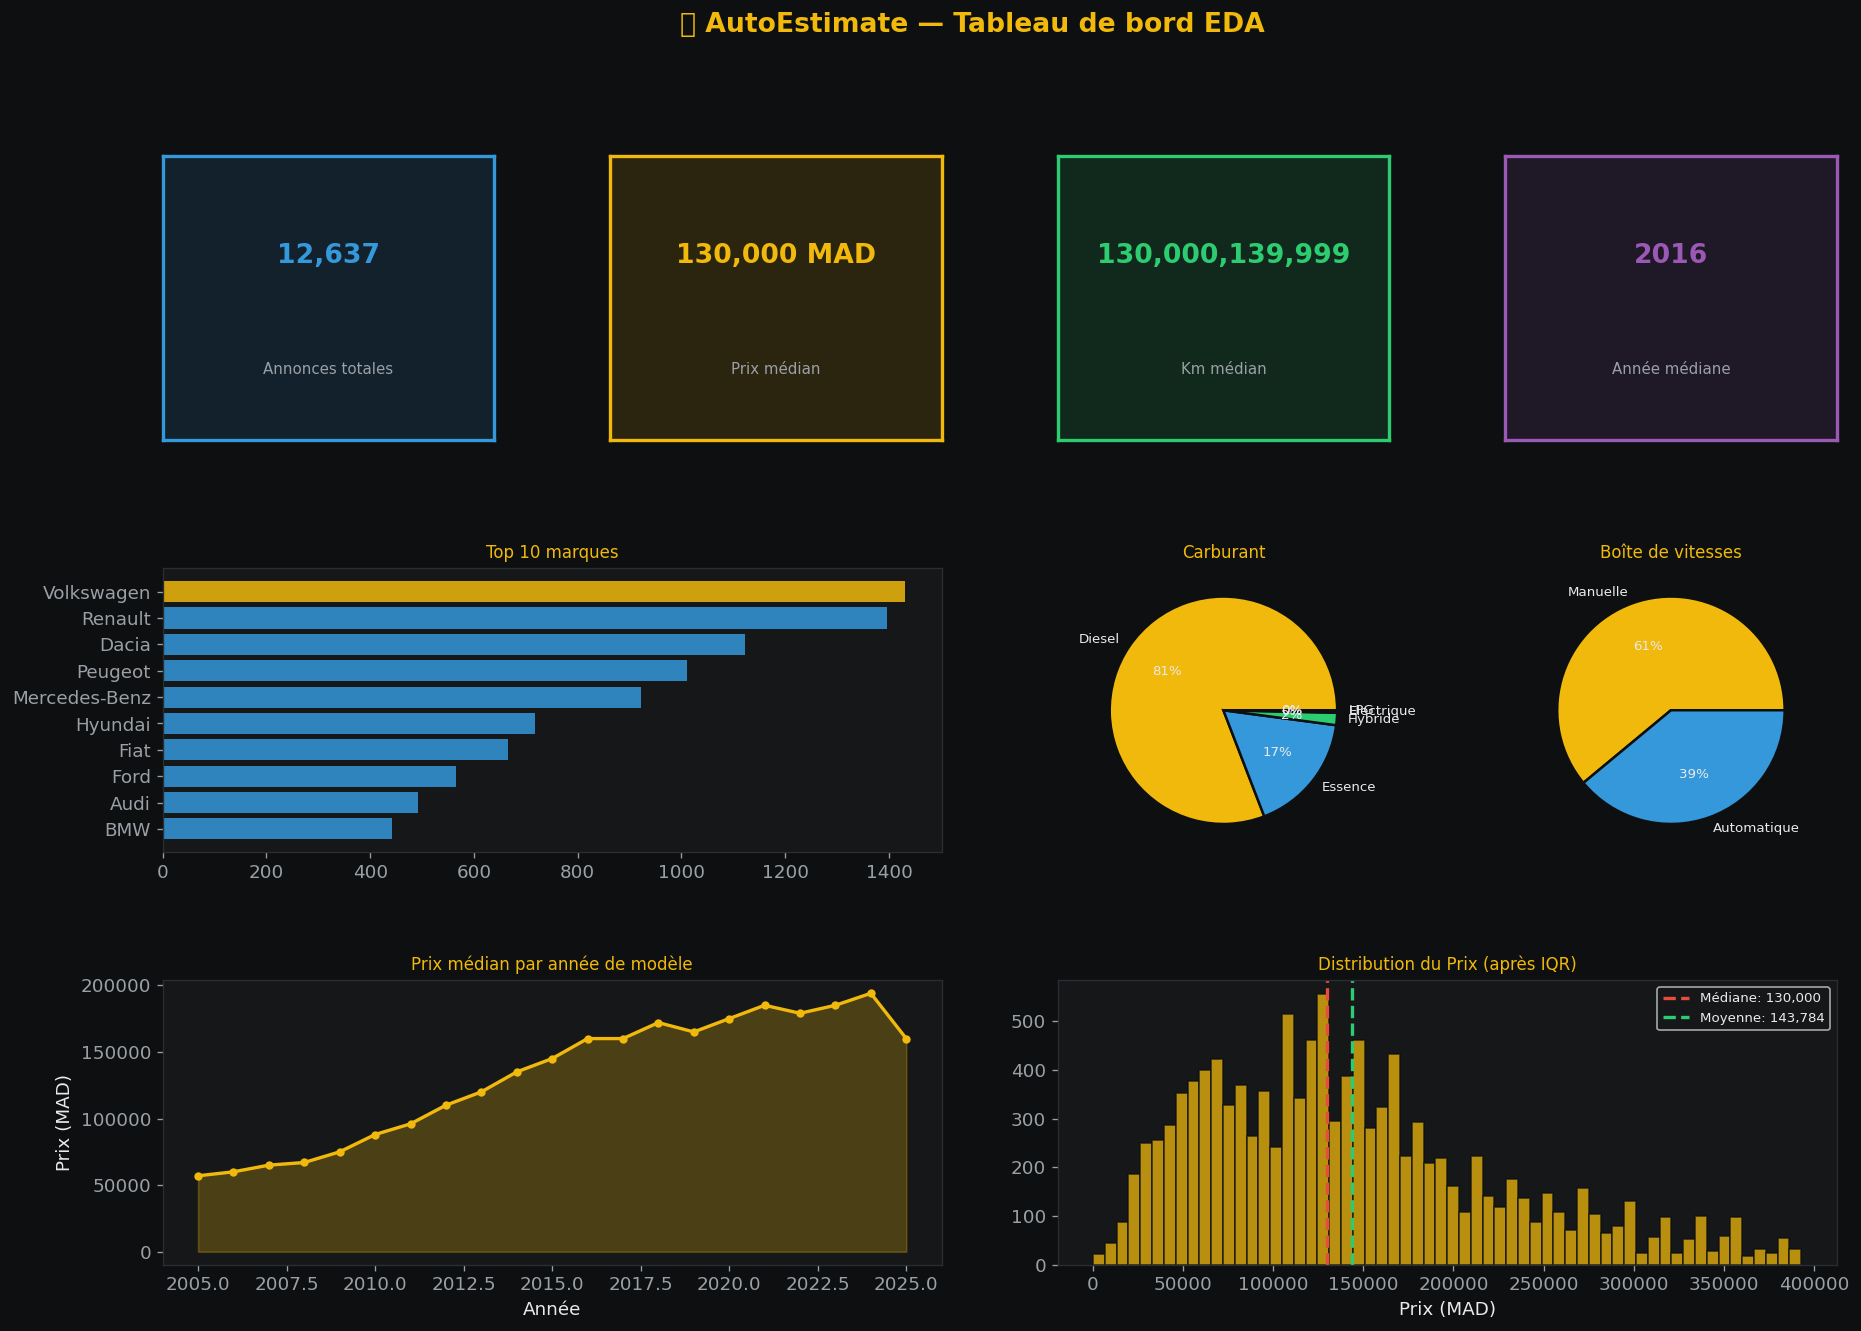


✅ Tous les graphiques EDA générés et sauvegardés !

Fichiers créés :
  📊 eda_01_missing.png
  📊 eda_02_prix_distribution.png
  📊 eda_03_outliers.png
  📊 eda_04_correlations.png
  📊 eda_05_scatter.png
  📊 eda_06_categoriques.png
  📊 eda_07_prix_par_categorie.png
  📊 eda_08_temporel.png
  📊 eda_09_equipements.png
  📊 eda_10_dashboard.png


In [14]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0d0f10')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("📊 AutoEstimate — Tableau de bord EDA", fontsize=16, color=GOLD,
             fontweight='bold', y=0.98)

d_s = d_clean2.copy()

# 1. KPI cards
kpis = [
    ("Annonces totales",  f"{len(d):,}",       '#3498db'),
    ("Prix médian",       f"{d_s['Prix'].median():,.0f} MAD", GOLD),
    ("Km médian",         f"{d_s['Kilométrage'].median():,.0f}", GREEN),
    ("Année médiane",     f"{int(d_s['Année-Modèle'].median())}",   '#9b59b6'),
]
for i, (label, val, color) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, i])
    ax_kpi.set_facecolor(color + '22')
    ax_kpi.set_xlim(0,1); ax_kpi.set_ylim(0,1)
    ax_kpi.text(0.5, 0.65, val,    ha='center', va='center', fontsize=16, fontweight='bold', color=color)
    ax_kpi.text(0.5, 0.25, label,  ha='center', va='center', fontsize=9,  color='#9aa0a6')
    for spine in ax_kpi.spines.values(): spine.set_edgecolor(color); spine.set_linewidth(2)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])

# 2. Top 10 marques
ax2 = fig.add_subplot(gs[1, :2])
top10 = d['Marque'].value_counts().head(10)
colors_t = [GOLD] + [BLUE] * 9
ax2.barh(top10.index[::-1], top10.values[::-1], color=colors_t[::-1], alpha=0.85)
ax2.set_title("Top 10 marques", color=GOLD, fontsize=10)

# 3. Carburant pie
ax3 = fig.add_subplot(gs[1, 2])
carb = d['Type de carburant'].value_counts()
ax3.pie(carb.values, labels=carb.index, colors=[GOLD,BLUE,GREEN,RED,'#9b59b6'][:len(carb)],
        autopct='%1.0f%%', textprops={'color':'#e8eaed','fontsize':8},
        wedgeprops={'edgecolor':'#0d0f10','linewidth':1.5})
ax3.set_title("Carburant", color=GOLD, fontsize=10)

# 4. Boite pie
ax4 = fig.add_subplot(gs[1, 3])
bv = d['Boite de vitesses'].value_counts()
ax4.pie(bv.values, labels=bv.index, colors=[GOLD,BLUE][:len(bv)],
        autopct='%1.0f%%', textprops={'color':'#e8eaed','fontsize':8},
        wedgeprops={'edgecolor':'#0d0f10','linewidth':1.5})
ax4.set_title("Boîte de vitesses", color=GOLD, fontsize=10)

# 5. Prix par année (ligne)
ax5 = fig.add_subplot(gs[2, :2])
pa  = d_s.dropna(subset=['Année-Modèle','Prix'])
pa  = pa[(pa['Année-Modèle']>=2005)&(pa['Année-Modèle']<=2025)]
pa2 = pa.groupby('Année-Modèle')['Prix'].median()
ax5.fill_between(pa2.index, pa2.values, alpha=0.25, color=GOLD)
ax5.plot(pa2.index, pa2.values, color=GOLD, linewidth=2, marker='o', markersize=4)
ax5.set_title("Prix médian par année de modèle", color=GOLD, fontsize=10)
ax5.set_xlabel("Année"); ax5.set_ylabel("Prix (MAD)")

# 6. Distribution prix
ax6 = fig.add_subplot(gs[2, 2:])
ax6.hist(d_s['Prix'].dropna(), bins=60, color=GOLD, alpha=0.75, edgecolor='#0d0f10')
ax6.axvline(d_s['Prix'].median(), color=RED,   linestyle='--', linewidth=2, label=f"Médiane: {d_s['Prix'].median():,.0f}")
ax6.axvline(d_s['Prix'].mean(),   color=GREEN, linestyle='--', linewidth=2, label=f"Moyenne: {d_s['Prix'].mean():,.0f}")
ax6.set_title("Distribution du Prix (après IQR)", color=GOLD, fontsize=10)
ax6.set_xlabel("Prix (MAD)"); ax6.legend(fontsize=8)

plt.savefig('eda_10_dashboard.png', bbox_inches='tight', facecolor='#0d0f10', dpi=130)
plt.show()
print("\n✅ Tous les graphiques EDA générés et sauvegardés !")
print("\nFichiers créés :")
import os
for f in sorted(os.listdir('.'))[:]:
    if f.startswith('eda_'):
        print(f"  📊 {f}")
